# Notebook 04 — EDA e estatística


Exemplo 1

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
CANDIDATE_FILES = [
    "raw_nir_data_Saturin.csv",
    "raw_mir_data_Saturin.csv",
    "raw_nir_data_saturin.csv",
    "raw_mir_data_saturin.csv",
]


def resolve_dataset():
    for file_name in CANDIDATE_FILES:
        candidate = DATA_DIR / file_name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Arquivo de solo não encontrado em {DATA_DIR}")


def read_csv_robust(file_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(file_path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível decodificar {file_path.name}")


df = read_csv_robust(resolve_dataset())

rename_map = {
    "Argilo": "Clay_gkg",
    "argila": "Clay_gkg",
    "clay": "Clay_gkg",
    "Clay_gkg": "Clay_gkg",
    "silte": "Silt_gkg",
    "silt": "Silt_gkg",
    "Silt_gkg": "Silt_gkg",
    "sand": "Sand_gkg",
    "areia": "Sand_gkg",
    "Sand_gkg": "Sand_gkg",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

for target, aliases in {
    "clay": ["Clay_gkg", "clay", "Argilo", "argila"],
    "sand": ["Sand_gkg", "sand", "areia"],
    "silt": ["Silt_gkg", "silt", "silte"],
}.items():
    matched = next((alias for alias in aliases if alias in df.columns), None)
    if matched is None:
        raise ValueError(f"Coluna de textura não encontrada para '{target}' no arquivo carregado.")
    df[target] = pd.to_numeric(df[matched], errors="coerce")

print(df[["clay", "sand", "silt"]].describe())


               clay          sand          silt
count  29249.000000  28571.000000  28629.000000
mean     209.994566    406.395465    347.757968
std      162.882335    266.374862    194.699103
min      -25.960814      0.000000      0.000000
25%       80.000000    170.000000    200.000000
50%      180.000000    390.000000    340.000000
75%      293.300000    619.820000    487.000000
max     1000.000000    996.000000    970.700000


C:\Users\PC\AppData\Local\Temp\ipykernel_15148\1038101243.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[target] = pd.to_numeric(df[matched], errors="coerce")


Exemplo 2


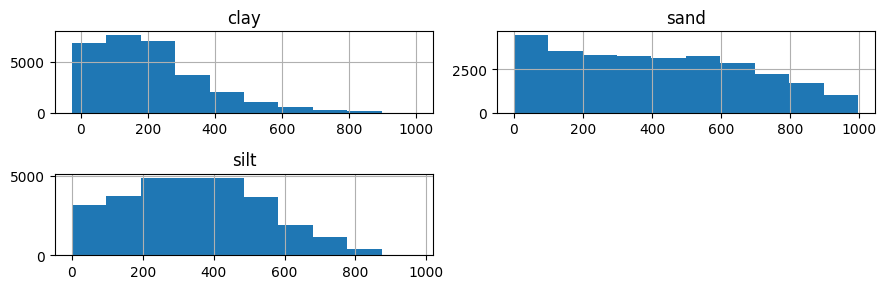

In [15]:
if 'df' not in globals():
    DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
    candidate_files = [
        "raw_nir_data_Saturin.csv",
        "raw_mir_data_Saturin.csv",
        "raw_nir_data_saturin.csv",
        "raw_mir_data_saturin.csv",
    ]
    dataset_path = next((DATA_DIR / name for name in candidate_files if (DATA_DIR / name).exists()), None)
    if dataset_path is None:
        raise FileNotFoundError(f"Arquivo de solo não encontrado em {DATA_DIR}")

    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            df = pd.read_csv(dataset_path, encoding=encoding, low_memory=False)
            break
        except UnicodeDecodeError:
            continue
    else:
        raise ValueError(f"Não foi possível decodificar {dataset_path.name}")

    rename_map = {
        "Argilo": "Clay_gkg",
        "argila": "Clay_gkg",
        "clay": "Clay_gkg",
        "Clay_gkg": "Clay_gkg",
        "silte": "Silt_gkg",
        "silt": "Silt_gkg",
        "Silt_gkg": "Silt_gkg",
        "sand": "Sand_gkg",
        "areia": "Sand_gkg",
        "Sand_gkg": "Sand_gkg",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

    for target, aliases in {
        "clay": ["Clay_gkg", "clay", "Argilo", "argila"],
        "sand": ["Sand_gkg", "sand", "areia"],
        "silt": ["Silt_gkg", "silt", "silte"],
    }.items():
        matched = next((alias for alias in aliases if alias in df.columns), None)
        if matched is None:
            continue
        df[target] = pd.to_numeric(df[matched], errors="coerce")

if not {"clay", "sand", "silt"}.issubset(df.columns):
    raise ValueError("As colunas de textura 'clay', 'sand' e 'silt' não foram encontradas no DataFrame.")

df[["clay", "sand", "silt"]].hist(figsize=(9, 3))
plt.tight_layout()


In [16]:
if 'df' not in globals():
    raise NameError("df não foi carregado. Execute a célula anterior antes desta.")

if not {"clay", "sand", "silt"}.issubset(df.columns):
    raise ValueError("As colunas de textura 'clay', 'sand' e 'silt' não foram encontradas no DataFrame.")

print(df[["clay", "sand", "silt"]].corr())


          clay      sand      silt
clay  1.000000 -0.569808  0.197099
sand -0.569808  1.000000 -0.599064
silt  0.197099 -0.599064  1.000000



Exemplo de Estatísticas descritivas e distribuição dos atributos laboratoriais

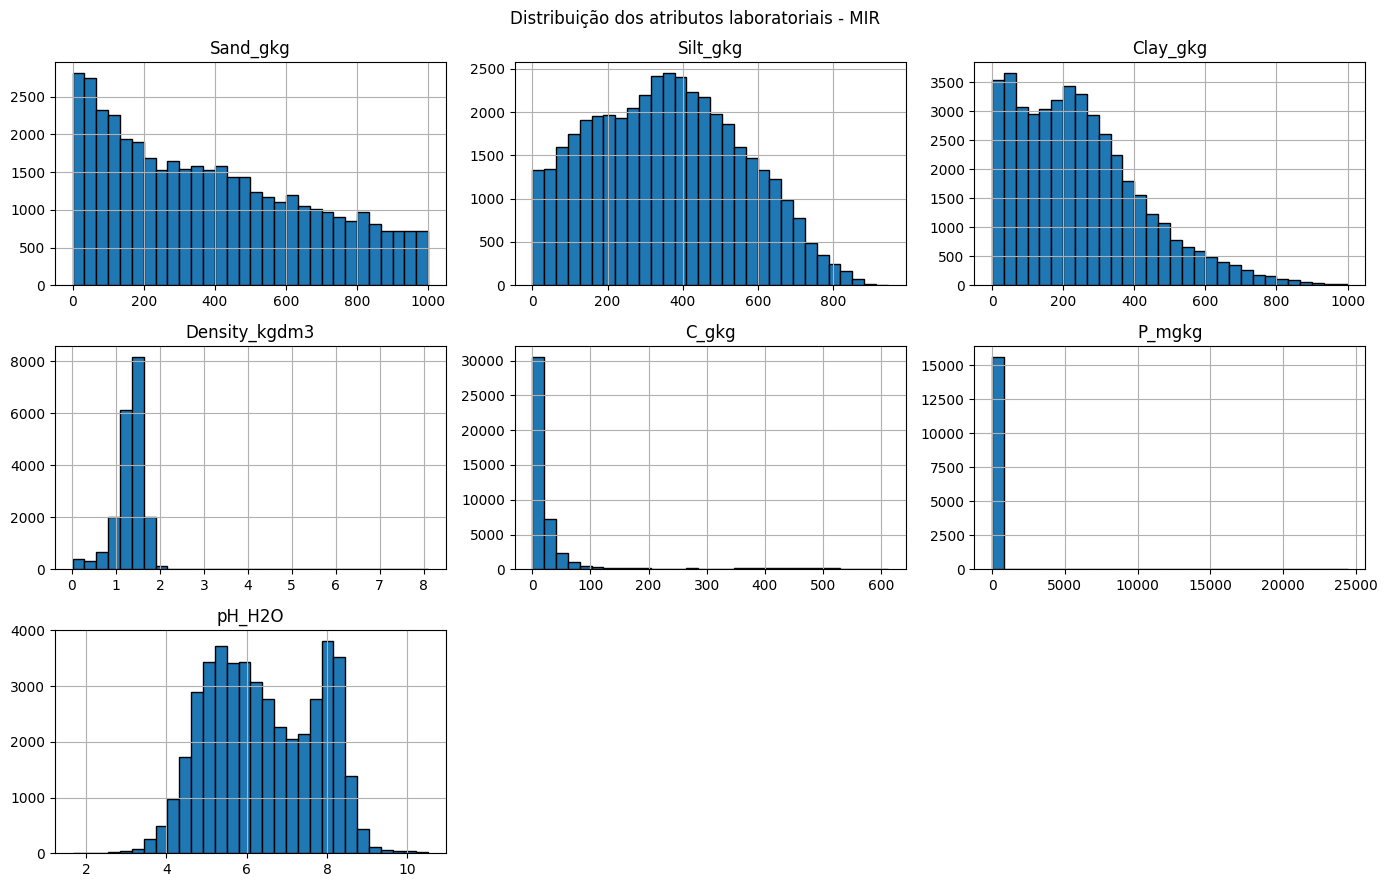

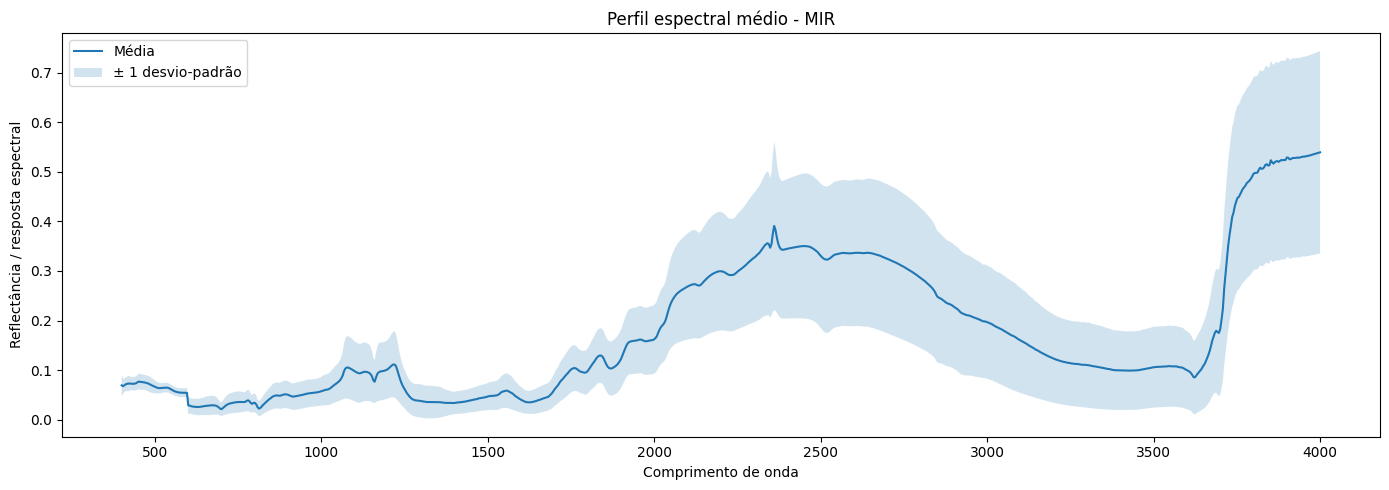

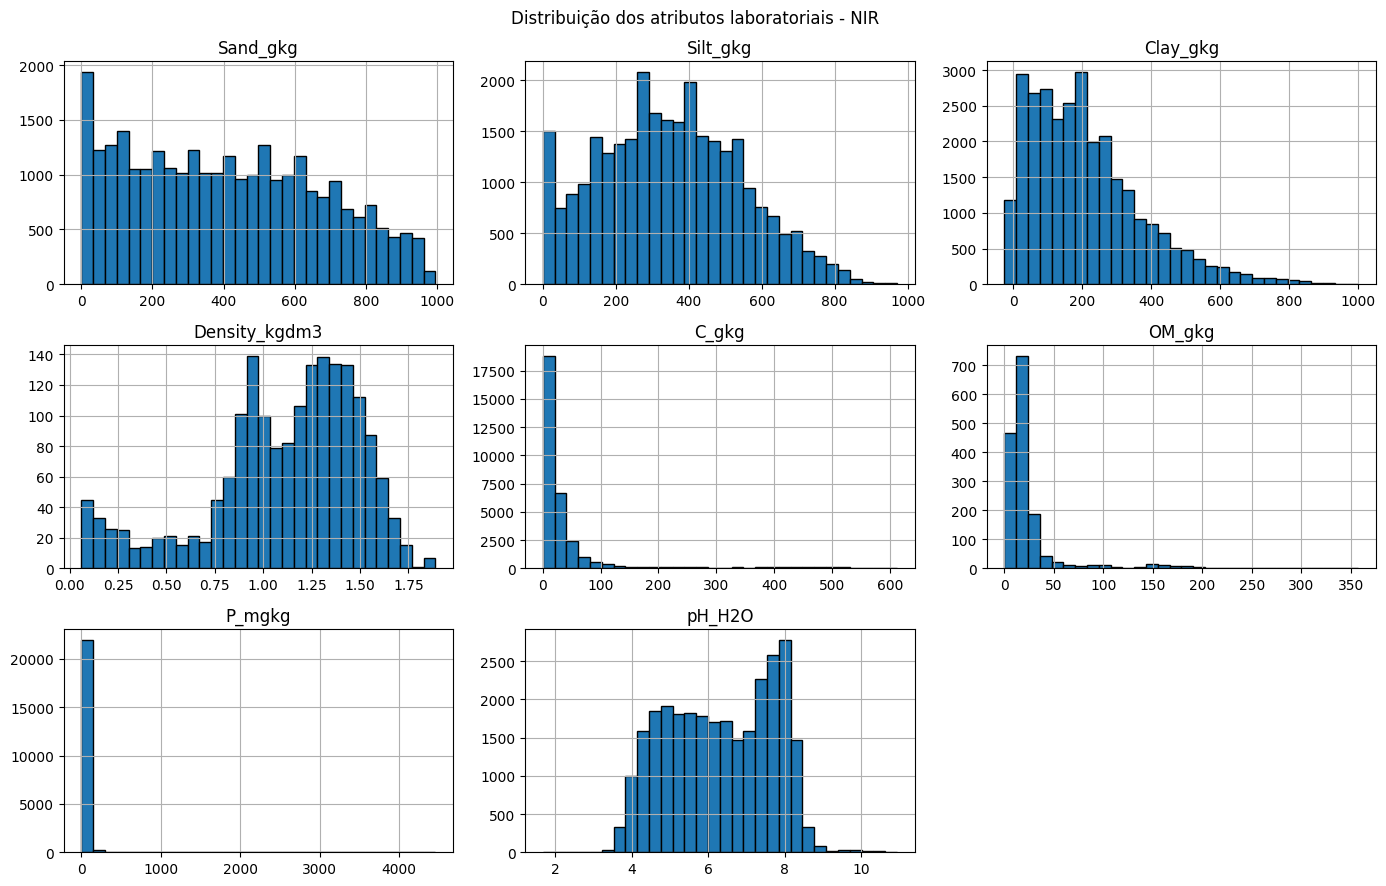

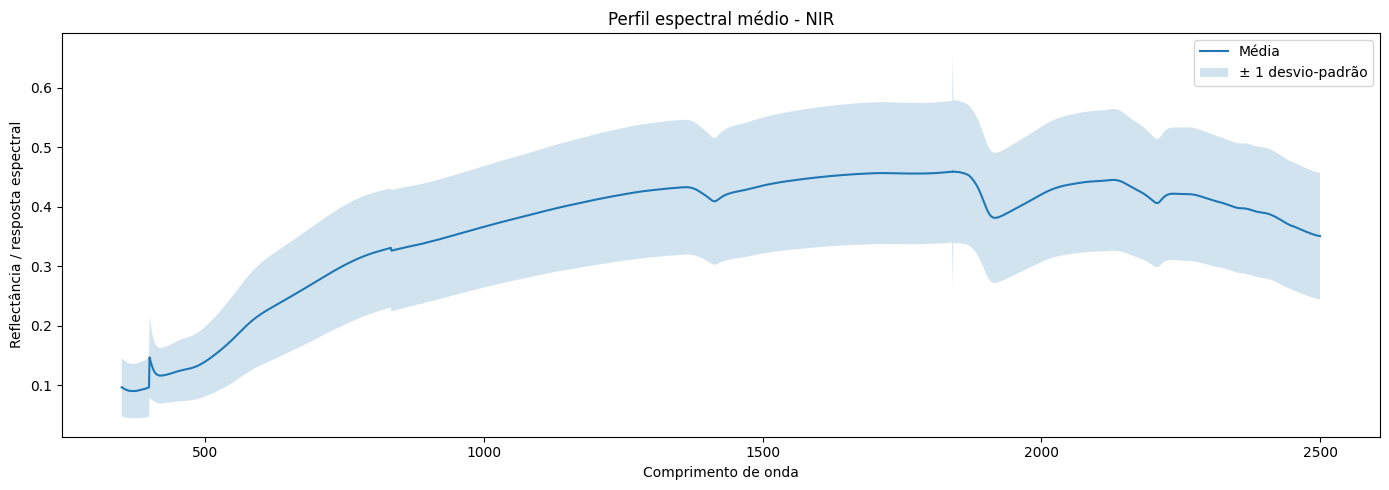

Resumo dos bancos espectrais


,sensor,codificacao,amostras,variaveis,bandas_espectrais,comprimento_onda_min,comprimento_onda_max,valores_ausentes,percentual_ausente,duplicatas
0,MIR,utf-8,49945,921,901,400.0,4000.0,2670194,5.805,0
1,NIR,cp1252,40137,2172,2151,350.0,2500.0,2430897,2.788,0


Estatísticas dos atributos laboratoriais


,atributo,sensor,count,mean,std,min,25%,50%,75%,max,ausentes,percentual_ausente,assimetria,curtose,outliers_IQR
0,Sand_gkg,MIR,42181.0,388.896639,279.381114,0.000000,140.000000,347.000000,603.000000,1000.00000,7764,15.545100,0.447281,-0.931646,0
1,Silt_gkg,MIR,42288.0,359.312310,197.687218,0.000000,200.000000,354.000000,504.000000,945.00000,7657,15.330864,0.176887,-0.759191,0
2,Clay_gkg,MIR,43804.0,249.600395,178.786749,0.000000,107.777000,223.742200,349.483875,1000.00000,6141,12.295525,0.903666,0.651127,856
3,Density_kgdm3,MIR,19822.0,1.321163,0.321861,0.014380,1.199910,1.374200,1.518193,8.10196,30123,60.312344,-0.854217,12.565004,1068
4,C_gkg,MIR,44850.0,38.138601,89.715321,0.020200,4.166600,11.353050,26.476625,611.84080,5095,10.201221,3.997883,15.853984,4770
5,P_mgkg,MIR,15616.0,23.122785,200.233480,0.000000,2.130150,6.762765,21.864760,24425.22709,34329,68.733607,116.002217,14128.712272,1756
6,pH_H2O,MIR,44974.0,6.415540,1.345440,1.670000,5.320000,6.280000,7.680000,10.52000,4971,9.952948,0.071415,-0.989006,1
7,Sand_gkg,NIR,28571.0,406.395465,266.374862,0.000000,170.000000,390.000000,619.820000,996.00000,11566,28.816304,0.226911,-1.028166,0
8,Silt_gkg,NIR,28629.0,347.757968,194.699103,0.000000,200.000000,340.000000,487.000000,970.70000,11508,28.671799,0.199122,-0.548354,16
9,Clay_gkg,NIR,29249.0,209.994566,162.882335,-25.960814,80.000000,180.000000,293.300000,1000.00000,10888,27.127090,1.139325,1.397490,761


Correlação de Spearman - MIR


,Sand_gkg,Silt_gkg,Clay_gkg,Density_kgdm3,C_gkg,P_mgkg,pH_H2O
Sand_gkg,1.000,-0.749,-0.750,0.235,-0.232,0.065,-0.150
Silt_gkg,-0.749,1.000,0.250,-0.185,0.248,0.057,0.108
Clay_gkg,-0.750,0.250,1.000,-0.130,0.148,-0.188,0.176
Density_kgdm3,0.235,-0.185,-0.130,1.000,-0.555,-0.203,0.140
C_gkg,-0.232,0.248,0.148,-0.555,1.000,0.163,0.029
P_mgkg,0.065,0.057,-0.188,-0.203,0.163,1.000,0.001
pH_H2O,-0.150,0.108,0.176,0.140,0.029,0.001,1.000


Correlação de Spearman - NIR


,Sand_gkg,Silt_gkg,Clay_gkg,Density_kgdm3,C_gkg,OM_gkg,P_mgkg,pH_H2O
Sand_gkg,1.000,-0.593,-0.571,0.351,-0.213,-0.515,-0.034,-0.218
Silt_gkg,-0.593,1.000,0.377,-0.192,-0.018,0.345,0.015,0.296
Clay_gkg,-0.571,0.377,1.000,-0.290,-0.116,0.326,-0.075,0.467
Density_kgdm3,0.351,-0.192,-0.290,1.000,-0.706,NaN,NaN,0.078
C_gkg,-0.213,-0.018,-0.116,-0.706,1.000,1.000,0.049,-0.475
OM_gkg,-0.515,0.345,0.326,NaN,1.000,1.000,0.065,-0.081
P_mgkg,-0.034,0.015,-0.075,NaN,0.049,0.065,1.000,-0.005
pH_H2O,-0.218,0.296,0.467,0.078,-0.475,-0.081,-0.005,1.000


Resultados salvos em: C:\Users\PC\Downloads\Material_Final_Data_Science_Solos\Material_Final_Data_Science_Solos\notebooks\outputs_eda_estatistica


In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bancos de dados espectrais disponíveis no projeto.
DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
OUTPUT_DIR = Path("outputs_eda_estatistica")
FILES = {
    "MIR": DATA_DIR / "raw_mir_data_Saturin.csv",
    "NIR": DATA_DIR / "raw_nir_data_Saturin.csv",
}
TARGET_COLUMNS = [
    "Sand_gkg", "Silt_gkg", "Clay_gkg", "Density_kgdm3",
    "C_gkg", "OM_gkg", "P_mgkg", "pH_H2O",
]


def is_wavelength_column(column_name):
    try:
        wavelength = float(str(column_name).strip().replace(",", "."))
    except (TypeError, ValueError):
        return False
    return 300 <= wavelength <= 4000


def read_csv_with_encoding(file_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(file_path, encoding=encoding, low_memory=False), encoding
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível identificar a codificação de {file_path.name}.")


def iqr_outlier_count(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    if values.empty:
        return 0
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum())


OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary_rows = []
target_statistics = []
correlations = {}

for sensor_name, file_path in FILES.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {file_path}")

    data, encoding = read_csv_with_encoding(file_path)
    data.columns = [str(column).strip() for column in data.columns]
    data = data.drop(columns=[
        column for column in data.columns
        if column.lower().startswith("unnamed")
    ], errors="ignore")
    data = data.dropna(axis=1, how="all").drop_duplicates().reset_index(drop=True)

    spectral_columns = [
        column for column in data.columns if is_wavelength_column(column)
    ]
    numeric_data = data.apply(pd.to_numeric, errors="coerce")
    target_columns_available = [
        column for column in TARGET_COLUMNS if column in data.columns
    ]

    summary_rows.append({
        "sensor": sensor_name,
        "codificacao": encoding,
        "amostras": len(data),
        "variaveis": len(data.columns),
        "bandas_espectrais": len(spectral_columns),
        "comprimento_onda_min": min(map(float, spectral_columns)) if spectral_columns else np.nan,
        "comprimento_onda_max": max(map(float, spectral_columns)) if spectral_columns else np.nan,
        "valores_ausentes": int(data.isna().sum().sum()),
        "percentual_ausente": round(float(data.isna().mean().mean() * 100), 3),
        "duplicatas": int(data.duplicated().sum()),
    })

    # Estatísticas descritivas e identificação de outliers dos atributos laboratoriais.
    if target_columns_available:
        target_numeric = numeric_data[target_columns_available]
        statistics = target_numeric.describe().T
        statistics["ausentes"] = target_numeric.isna().sum()
        statistics["percentual_ausente"] = target_numeric.isna().mean() * 100
        statistics["assimetria"] = target_numeric.skew()
        statistics["curtose"] = target_numeric.kurtosis()
        statistics["outliers_IQR"] = [
            iqr_outlier_count(target_numeric[column])
            for column in target_columns_available
        ]
        statistics.insert(0, "sensor", sensor_name)
        statistics.to_csv(OUTPUT_DIR / f"estatisticas_{sensor_name.lower()}.csv")
        target_statistics.append(statistics.reset_index(names="atributo"))

        correlations[sensor_name] = target_numeric.corr(method="spearman")
        correlations[sensor_name].to_csv(
            OUTPUT_DIR / f"correlacoes_spearman_{sensor_name.lower()}.csv"
        )

        axes = target_numeric.hist(figsize=(14, 9), bins=30, edgecolor="black")
        plt.suptitle(f"Distribuição dos atributos laboratoriais - {sensor_name}")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"distribuicoes_atributos_{sensor_name.lower()}.png", dpi=150)
        plt.show()
        plt.close("all")

    # Resumo estatístico das bandas: média, desvio-padrão e cobertura.
    spectral_numeric = numeric_data[spectral_columns]
    spectral_summary = pd.DataFrame({
        "comprimento_onda": [float(column) for column in spectral_columns],
        "media": spectral_numeric.mean().to_numpy(),
        "desvio_padrao": spectral_numeric.std().to_numpy(),
        "mediana": spectral_numeric.median().to_numpy(),
        "ausentes": spectral_numeric.isna().sum().to_numpy(),
    }).sort_values("comprimento_onda")
    spectral_summary.to_csv(
        OUTPUT_DIR / f"resumo_bandas_{sensor_name.lower()}.csv", index=False
    )

    # Curvas médias e variabilidade espectral.
    ordered = spectral_summary.sort_values("comprimento_onda")
    plt.figure(figsize=(14, 5))
    plt.plot(ordered["comprimento_onda"], ordered["media"], label="Média")
    plt.fill_between(
        ordered["comprimento_onda"],
        ordered["media"] - ordered["desvio_padrao"],
        ordered["media"] + ordered["desvio_padrao"],
        alpha=0.2,
        label="± 1 desvio-padrão",
    )
    plt.xlabel("Comprimento de onda")
    plt.ylabel("Reflectância / resposta espectral")
    plt.title(f"Perfil espectral médio - {sensor_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"perfil_espectral_{sensor_name.lower()}.png", dpi=150)
    plt.show()
    plt.close("all")

summary = pd.DataFrame(summary_rows)
summary.to_csv(OUTPUT_DIR / "resumo_eda.csv", index=False)

if target_statistics:
    all_target_statistics = pd.concat(target_statistics, ignore_index=True)
    all_target_statistics.to_csv(OUTPUT_DIR / "estatisticas_atributos.csv", index=False)
else:
    all_target_statistics = pd.DataFrame()

print("Resumo dos bancos espectrais")
display(summary)
if not all_target_statistics.empty:
    print("Estatísticas dos atributos laboratoriais")
    display(all_target_statistics)
for sensor_name, correlation in correlations.items():
    print(f"Correlação de Spearman - {sensor_name}")
    display(correlation.round(3))
print(f"Resultados salvos em: {OUTPUT_DIR.resolve()}")
